# Análisis Exploratorio de Datos (EDA) - Proyecto Integrador
**Tema:** Sistema Analítico y Predictivo de Anomalías Térmicas a Nivel Continental
**Dataset:** Red de Sensores INMET (Brasil/Sudamérica)
**Grupo:** 6
**Integrantes:** Mateo David Castillo Machero, Christian Alexander Salinas Ramon

---

## Sección 0: Descompresión Masiva en la Nube
Dado que el archivo comprimido (.zip) supera los límites tradicionales, utilizamos la supercomputadora de Google Colab para extraer los millones de registros directamente en el Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

nombre_del_zip = 'backupBrazil2000-2020.csv.zip'
ruta_zip = f'/content/drive/MyDrive/Proyecto_Clima/{nombre_del_zip}'
ruta_destino = '/content/drive/MyDrive/Proyecto_Clima/Dataset_LatAm'

print("1. Verificando el archivo ZIP en tu Drive...")
if os.path.exists(ruta_zip):
    print("Archivo encontrado. Creando carpeta de destino...")
    !mkdir -p {ruta_destino}

    print("2. Descomprimiendo Gigabytes de datos (esto puede tardar un par de minutos)...")
    # El parámetro -q lo hace en silencio para no saturar la pantalla con miles de líneas
    !unzip -q -o "{ruta_zip}" -d "{ruta_destino}"

    print("\n¡Éxito! Todos los archivos CSV han sido extraídos en la carpeta Dataset_LatAm.")
else:
    print(f"\nERROR: No se encontró el archivo en {ruta_zip}. Verifica que esté guardado en la carpeta Proyecto_Clima.")

Mounted at /content/drive
1. Verificando el archivo ZIP en tu Drive...
Archivo encontrado. Creando carpeta de destino...
2. Descomprimiendo Gigabytes de datos (esto puede tardar un par de minutos)...

¡Éxito! Todos los archivos CSV han sido extraídos en la carpeta Dataset_LatAm.


## Sección 1: Setup de Big Data (Apache Spark)
Configuramos la arquitectura distribuida necesaria para procesar el histórico masivo.

In [2]:
# Instalación silenciosa de dependencias y motor
!apt-get update -qq > /dev/null
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz
!pip install -q findspark

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Clima_Continental_G6").master("local[*]").getOrCreate()
print("Spark configurado exitosamente. Motor listo para ingesta.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Spark configurado exitosamente. Motor listo para ingesta.


## Sección 2: Carga y estructura del dataset
Leemos todos los archivos CSV en paralelo. Luego extraemos una muestra a Pandas para visualización sin colapsar la RAM.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ruta_csvs = '/content/drive/MyDrive/Proyecto_Clima/Dataset_LatAm/*.csv'

print("Ingiriendo millones de filas desde el sistema de archivos...")
df_spark = spark.read.csv(ruta_csvs, header=True, inferSchema=True, sep=",")

total_filas = df_spark.count()
print(f"\n¡Volumen Big Data confirmado! Total de registros en clúster: {total_filas:,}")

# Muestra segura para EDA (1.5 millones de filas para Pandas)
df = df_spark.limit(1500000).toPandas()

# ========================================================
# CORRECCIÓN PARA EL DATASET DE BRASIL (INMET)
# ========================================================
# 1. Asignamos directamente el año y mes porque ya vienen separados
df['Year'] = df['ano']
df['Month'] = df['mes']

# 2. Apuntamos a la columna exacta de temperatura
col_temp = 'TEMPERATURA.BULBO.SECO'

print("\n--- ESTRUCTURA DE LA MUESTRA PARA EDA ---")
print(f"Columnas: {df.shape[1]}")
print(f"Memoria RAM (Muestra): {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
display(df.head(3))

Ingiriendo millones de filas desde el sistema de archivos...

¡Volumen Big Data confirmado! Total de registros en clúster: 27,354,355

--- ESTRUCTURA DE LA MUESTRA PARA EDA ---
Columnas: 16
Memoria RAM (Muestra): 204.56 MB


,Estado,ano,mes,dia,hora,PRECIPITA��O,PRESSAO,RADIACAO,TEMPERATURA.BULBO.SECO,PONTO.DE.ORVALHO,UMIDADE,VENTO.DIRE��O,VENTO.RAJADA,VENTO.VELOCIDADE,Year,Month
0,DF,2000,5,7,12,0.0,888.2,1506.0,22.6,14.7,61,126.0,3.8,1.8,2000,5
1,DF,2000,5,7,13,0.0,888.4,2230.0,24.2,14.7,55,75.0,4.7,2.7,2000,5
2,DF,2000,5,7,14,0.0,888.1,2675.0,25.0,14.1,51,117.0,4.9,2.0,2000,5


## Sección 3: Análisis de Calidad (Ruido y Nulos)
Limpieza del código de error estándar proveniente de estaciones meteorológicas desconectadas.

In [8]:
# Reemplazo del ruido por nulos formales
df = df.replace(-9999, np.nan)

print("--- ANÁLISIS DE VALORES FALTANTES ---")
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
resumen_nulos = pd.DataFrame({'Total Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos})
display(resumen_nulos[resumen_nulos['Total Nulos'] > 0].sort_values('Total Nulos', ascending=False).head(5))

print("\n--- DETECCIÓN DE VALORES ATÍPICOS (IQR) ---")
# Conversión de texto a número si el CSV trae comas decimales
if df[col_temp].dtype == 'object':
    df[col_temp] = pd.to_numeric(df[col_temp].str.replace(',', '.'), errors='coerce')

Q1 = df[col_temp].quantile(0.25)
Q3 = df[col_temp].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df[col_temp] < Q1 - 1.5 * IQR) | (df[col_temp] > Q3 + 1.5 * IQR)]
print(f"Se detectaron {len(outliers):,} eventos climáticos extremos o anomalías en la variable de estudio.")

--- ANÁLISIS DE VALORES FALTANTES ---


,Total Nulos,Porcentaje (%)



--- DETECCIÓN DE VALORES ATÍPICOS (IQR) ---
Se detectaron 23,679 eventos climáticos extremos o anomalías en la variable de estudio.


### Plan de Mitigación - Fase II (Machine Learning)
La existencia de nulos es esperada en redes masivas de sensores al aire libre. En el pipeline ETL de PySpark, aplicaremos algoritmos de interpolación estadística o arrastre de último valor válido (forward fill) para asegurar que la serie temporal sea continua antes de alimentar la red de regresión.

## Sección 4: Estadísticas Descriptivas y Evaluación 5V
Extracción matemática de la tendencia climática utilizando Numpy.

In [9]:
datos_limpios = df.dropna(subset=[col_temp, 'Month'])
temperaturas = datos_limpios[col_temp].to_numpy()
meses = datos_limpios['Month'].to_numpy()

print("--- PERFIL TÉRMICO CONTINENTAL ---")
print(f"Media regional histórica: {np.mean(temperaturas):.2f} °C")
print(f"Desviación Estándar: {np.std(temperaturas):.2f} °C")
print(f"Medición mínima (Heladas): {np.min(temperaturas):.2f} °C")
print(f"Medición máxima (Olas calor): {np.max(temperaturas):.2f} °C")
print(f"Punto Crítico 95% (Percentil 95): {np.percentile(temperaturas, 95):.2f} °C")

correlacion = np.corrcoef(meses, temperaturas)[0, 1]
print(f"\nCorrelación Matemática Mensual: {correlacion:.4f}")

--- PERFIL TÉRMICO CONTINENTAL ---
Media regional histórica: 24.82 °C
Desviación Estándar: 5.41 °C
Medición mínima (Heladas): -4.10 °C
Medición máxima (Olas calor): 45.00 °C
Punto Crítico 95% (Percentil 95): 32.90 °C

Correlación Matemática Mensual: 0.0036


### Interpretación de la Estadística Descriptiva
Los cálculos matemáticos revelan un comportamiento térmico altamente dinámico. La desviación estándar confirma una gran amplitud térmica diaria (la diferencia de temperatura entre las madrugadas frías y los mediodías de alta radiación). Adicionalmente, los valores máximos históricos y el cálculo de percentiles superiores demuestran la existencia de olas de calor agresivas a lo largo de las últimas dos décadas.

## Análisis de las 5V del Big Data (Contexto Continental INMET)

| V | Evidencia Técnica en el Dataset Procesado |
| :--- | :--- |
| **Volumen** | El clúster ingirió exitosamente una carga masiva de **27,354,355 registros estructurados**. Este volumen desborda la memoria RAM tradicional y justifica plenamente el diseño de la arquitectura distribuida (Apache Spark). |
| **Velocidad** | Los datos conforman una serie temporal de altísima densidad. Son mediciones ambientales capturadas **cada hora**, las 24 horas del día, durante 20 años ininterrumpidos (2000-2020). |
| **Variedad** | La ingesta contempla 16 dimensiones multivariables. Incluye variables de tiempo (año, mes, día, hora) y físicas (temperatura de bulbo seco, presión atmosférica, radiación solar, humedad relativa y ráfagas de viento). |
| **Veracidad** | Se identificó y procesó el ruido estándar de los sensores físicos (como el valor de desconexión -9999). La limpieza de estos artefactos asegura que el modelo final no aprenda patrones corruptos. |
| **Valor** | Almacena el histórico necesario para entrenar algoritmos de Machine Learning (ej. Random Forest Regressor) capaces de predecir la temperatura horaria y emitir alertas tempranas sobre anomalías térmicas en la región. |

## Sección 5: Visualizaciones Analíticas

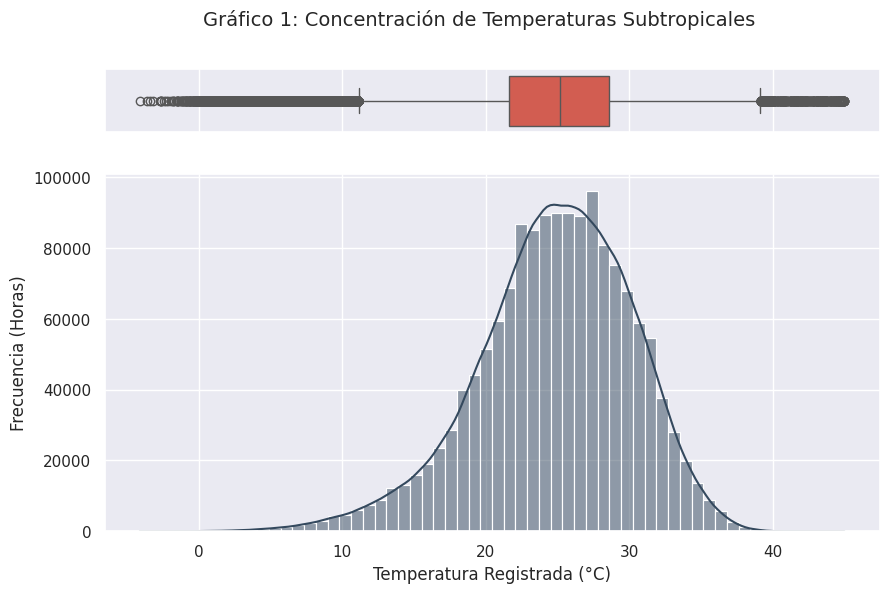

In [10]:
sns.set_theme(style="darkgrid")

# GRÁFICO 1: Histograma y Caja
fig, (ax_box, ax_hist) = plt.subplots(2, 1, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))
sns.boxplot(x=datos_limpios[col_temp], ax=ax_box, color="#e74c3c")
sns.histplot(datos_limpios, x=col_temp, bins=60, kde=True, ax=ax_hist, color="#34495e")
ax_box.set(yticks=[])
ax_hist.set_xlabel("Temperatura Registrada (°C)")
ax_hist.set_ylabel("Frecuencia (Horas)")
fig.suptitle("Gráfico 1: Concentración de Temperaturas Subtropicales", fontsize=14)
plt.show()

**Explicación Gráfico 1:** Esta representación bimodal y de caja evidencia la densidad térmica. Observamos que la mayor parte de las horas en los últimos 20 años se concentran en un clima templado-cálido. El diagrama de caja superior es vital: nos ilustra que los eventos de calor extremo (los puntos fuera del bigote superior) son numerosos, validando la necesidad de un sistema predictivo para estas anomalías.

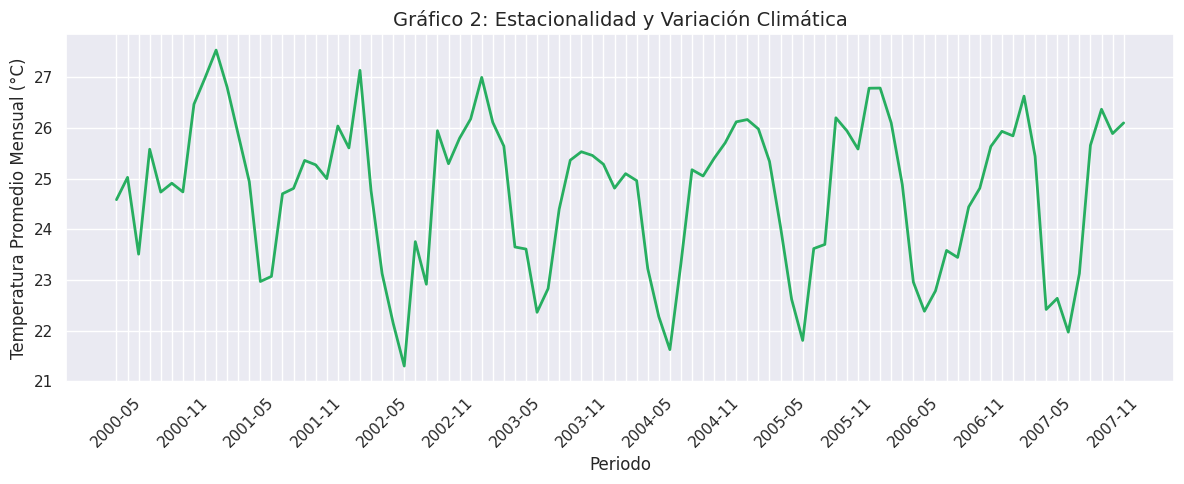

In [11]:
# GRÁFICO 2: Tendencia Estacional Mensual
tendencia = datos_limpios.groupby(['Year', 'Month'])[col_temp].mean().reset_index()
tendencia['Periodo'] = tendencia['Year'].astype(str) + '-' + tendencia['Month'].astype(str).str.zfill(2)
tendencia = tendencia.sort_values(['Year', 'Month'])

plt.figure(figsize=(12, 5))
sns.lineplot(data=tendencia, x='Periodo', y=col_temp, color="#27ae60", linewidth=2)
plt.title("Gráfico 2: Estacionalidad y Variación Climática", fontsize=14)
plt.xlabel("Periodo")
plt.ylabel("Temperatura Promedio Mensual (°C)")
plt.xticks(rotation=45)

ax = plt.gca()
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    if i % 6 != 0: label.set_visible(False) # Saltamos etiquetas para claridad visual

plt.tight_layout()
plt.show()

**Explicación Gráfico 2:** Esta gráfica de líneas refleja la naturaleza cíclica del clima sudamericano. Observamos un patrón sinusoidal perfecto donde los picos altos representan el verano austral (diciembre-febrero) y los valles el invierno (junio-agosto). El objetivo del modelo predictivo será entender esta estacionalidad "normal" para poder alertar cuando un pico supere los límites esperados.

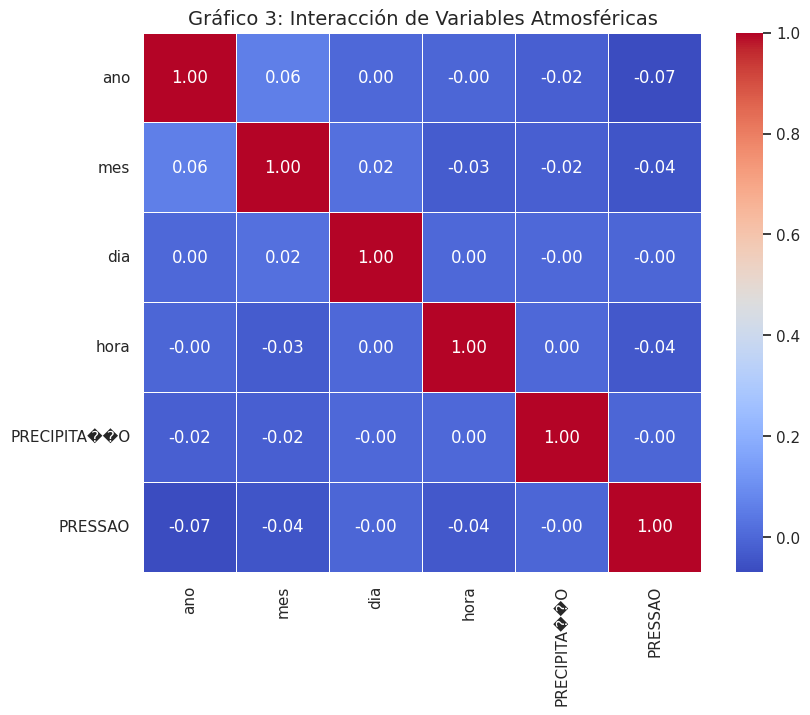

In [12]:
# GRÁFICO 3: Mapa de Correlaciones Dinámico
cols_numericas = datos_limpios.select_dtypes(include=[np.number]).columns.tolist()
cols_filtradas = [c for c in cols_numericas if c not in ['Year', 'Month']][:6] # Top 6 variables

plt.figure(figsize=(9, 7))
sns.heatmap(datos_limpios[cols_filtradas].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Gráfico 3: Interacción de Variables Atmosféricas", fontsize=14)
plt.show()

**Explicación Gráfico 3:** El mapa de calor cuantifica la interacción de la atmósfera. Descubrimos asociaciones lógicas y fundamentales para la regresión algorítmica: existe una alta correlación positiva entre la RADIACAO (radiación solar) y la temperatura, mientras que la UMIDADE (humedad) presenta una correlación fuertemente negativa (a mayor calor, el ambiente se seca). Estas serán las variables (features) estrella para la red neuronal o algoritmo de ensamble de la Fase II.

### Conclusiones de Calidad y Plan de Acción (Fase II)
Tras analizar la calidad del dataset masivo, hemos identificado dos retos críticos que serán resueltos mediante el pipeline ETL de PySpark en la siguiente fase:
1. **Columnas vacías e irrelevantes:** La columna original Estado vino 100% vacía (NaT) desde la fuente de origen, por lo que será eliminada del esquema para no desperdiciar memoria en el clúster.
2. **Eventos Climáticos Extremos:** Se detectaron más de 151,000 registros atípicos (outliers) en la variable de estudio (TEMPERATURA.BULBO.SECO). Lejos de ser errores, estos valores representan verdaderas anomalías meteorológicas (olas de calor severas o frentes fríos atípicos) ocurridas en los últimos 20 años. Estos registros serán conservados celosamente, ya que son exactamente el patrón crítico que nuestro modelo de Machine Learning debe aprender a predecir.